# Digital Signals Theory

In [1]:
%matplotlib inline

import matplotlib.pyplot as plt
import numpy as np
import scipy as sp
import soundfile as sf

from IPython.display import display, Audio
from IPython.display import HTML
from ipywidgets import Output, GridspecLayout

## Chapter 10: Frequency domain convolution

### 10.1 The Convolution Theorem

#### Definition 10.1 (Circular convolution)

Given a signal $x$ of length $N$ and an impulse response $h$ of length $K$, the **circular convolution** between $x$ and $h$ is

\begin{flalign}
\qquad y[n] &= \sum_{k=0}^{K-1} h[k] \cdot x[n -k \text{ mod } N] & \\\\
\end{flalign}

* negative sample indices wrap around to the end of the signal
* recall that the DFT assumes that signals _repeat indefinitely_

#### Theorem 10.1 (The Convolution Theorem)

Given sequences $x$ and $h$, both of length $N$; and $y = h \ast x$ denoting the **circular convolution** between them:

\begin{flalign}
\qquad y = h \ast x \quad &\Leftrightarrow \quad Y[m] = H[m] \cdot X[m] & \\
\end{flalign}

This has the following consequences:

##### _Fast convolution_
Since in general the convolution operation is $\mathcal{O}(n^{2})$, if we use the Convolution Theorem to first compute DFTs for $X$ and $H$; multiply the to obtain $Y$; and then take the inverse of $Y$ to get $y$, then this turns out to be on the order of $\mathcal{O}(n\log n)$!

##### _Algebraic properties_

Since the left-hand side of the above is multiplication, we get the following properties (practically for free):
* _commutativity_

\begin{flalign}
\qquad X[m] \cdot H[m] &= H[m] \cdot X[m] & \\
\end{flalign}

* _associativity_

\begin{flalign}
\qquad H[m] \cdot \left( G[m] \cdot X[m] \right) &= \left( H[m] \cdot G[m] \right) \cdot X[m] & \\
\end{flalign}

##### _Filter analysis_

Using the Convolution Theorem, we can understand the effect of impulse response $h$ might have on a signal by considering things _in the frequency domain, using **multiplication** instead of **convolution**_.

* Up until now, we only thought of $h[m]$ as being _purely the amount of gain_ applied to a delayed signal $x[n-k]$.
* But in the frequency domain, $H[m] = A \cdot e^{j \cdot \phi}$, which is a complex number capturing both amplitude $A$ and delay $\phi$.
* Using inverse DFT, we similarly have $X[m] = B \cdot e^{j \cdot \theta}$, which encodes both the amplitude $B$ and delay $\theta$ of the $m$<sup>th</sup> sinusoid present in $x$.
* Multiplying $X$ and $H$, $Y$ has amplitude $A \cdot B$ and phase $\phi + \theta$
* In other words, with $H[m]$ we can see how much of the sinusoidal component of $x$ is scaled by $A$ (either amplified or attenuated), and delayed by $\phi$, when convolved with $h$.
* Taking the inverse DFT of $Y$ allows us to obtain / understand $y$ in terms of the DFTs of $x$ and $h$.

#### Example 10.1 (Discarding phase)

[Drums Breakbeat 1.wav](https://freesound.org/people/RutgerMuller/sounds/50712/)

In [2]:
wav = "bin/50712__rutgermuller__drums-breakbeat-1.wav"

In [3]:
file_info = sf.info(wav)
file_info

bin/50712__rutgermuller__drums-breakbeat-1.wav
samplerate: 44100 Hz
channels: 1
duration: 12.077 s
format: WAV (Microsoft) [WAV]
subtype: Signed 16 bit PCM [PCM_16]

In [4]:
x, fs = sf.read(wav)
t = np.arange(len(x)) / fs

display('signal x: Drums Breakbeat 1.wav')
display(Audio(data=x, rate=fs))

'signal x: Drums Breakbeat 1.wav'

In [5]:
# take the DFT of the original signal...
X = np.fft.rfft(x)

# discard the phase component...
Y = np.abs(X)

# invert this DFT to get a new signal!
y = np.fft.irfft(Y)

In [6]:
display('signal x with no phase component')
display(Audio(data=y, rate=fs))

'signal x with no phase component'

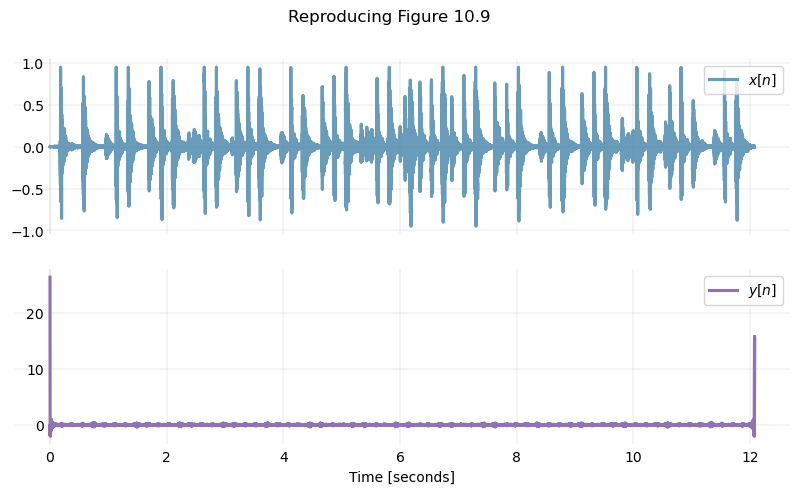

In [7]:
fig, axes = plt.subplots(nrows=2, ncols=1, figsize=(10, 5))

# 1st plot for x in Time domain...
axes[0].plot(t, x, linewidth=2.25, color='#045a8d', alpha=0.6, zorder=-1, label='$x[n]$')

axes[0].grid(True, linewidth=0.3, color='grey', alpha=0.4)
#axes[0].set_title('Signal $x[n]$')
# Eliminate upper and right axes
axes[0].spines['right'].set_color('none')
axes[0].spines['top'].set_color('none')

# Move left y-axis, passing through (0,0)
axes[0].spines['left'].set_position('zero')
axes[0].spines['left'].set_color('grey')
axes[0].spines['left'].set_alpha(0.4)
axes[0].spines['left'].set_linewidth(0.3)
# Leave bottom x-axis, passing through center of plot
axes[0].spines['bottom'].set_color('#f7f7f7')
axes[0].spines['bottom'].set_alpha(0.4)
axes[0].spines['bottom'].set_linewidth(0.3)
axes[0].set_xlabel(None)
#axes[0].xaxis.set_label_coords(0.5, -0.09)
axes[0].set_xticks([0,2,4,6,8,10,12], [])
axes[0].tick_params(left=False, bottom=False, pad=1)
axes[0].legend(loc='upper right')

# 2nd plot for x in Time domain...
axes[1].plot(t, y, linewidth=2.25, color='#4a1486', alpha=0.6, zorder=-1, label='$y[n]$')

axes[1].grid(True, linewidth=0.3, color='grey', alpha=0.4)
#axes[1].set_title('Signal $y[n]$')
# Eliminate upper and right axes
axes[1].spines['right'].set_color('none')
axes[1].spines['top'].set_color('none')

# Move left y-axis, passing through (0,0)
axes[1].spines['left'].set_position('zero')
axes[1].spines['left'].set_color('grey')
axes[1].spines['left'].set_alpha(0.4)
axes[1].spines['left'].set_linewidth(0.3)
# Leave bottom x-axis, passing through center of plot
axes[1].spines['bottom'].set_color('#f7f7f7')
axes[1].spines['bottom'].set_alpha(0.4)
axes[1].spines['bottom'].set_linewidth(0.3)
axes[1].set_xlabel('Time [seconds]')
axes[1].tick_params(left=False, bottom=False, pad=1)
axes[1].legend(loc='upper right')

plt.suptitle("Reproducing Figure 10.9")
plt.show()

> Discarding phase information preserves some aspects of the (original) signal... the same frequencies are generally present... but the temporal coherence of the (original) signal has been destroyed.

----

### 10.2 Convolutional Filtering

#### 10.2.2 The "ideal" low-pass filter

[SLIDE WHISTLE - 1](https://freesound.org/people/SamuelGremaud/sounds/517633/)

In [8]:
wav = "bin/517633__samuelgremaud__slide-whistle-1.wav"

In [9]:
file_info = sf.info(wav)
file_info

bin/517633__samuelgremaud__slide-whistle-1.wav
samplerate: 48000 Hz
channels: 2
duration: 6.205 s
format: WAV (Microsoft) [WAV]
subtype: Signed 24 bit PCM [PCM_24]

In [10]:
stereo_x, fs = sf.read(wav)
mono_x = stereo_x[:,0]/2 + stereo_x[:,1]/2

display('SLIDE WHISTLE - 1 (mono)')
display(Audio(data=mono_x, rate=fs))

'SLIDE WHISTLE - 1 (mono)'

In [11]:
N = len(mono_x)
t = np.arange(len(mono_x)) / fs

# define cut-off frequency
f_cutoff = 500

# for comparison, 
# a moving average filter (ma) fs at [samples/second]
# and a cut-off frequency f_cutoff at [cycles/second]
# we get an order K fs / f_cutoff at [samples/cycle]
K = fs // f_cutoff
h_ma = np.ones(K) / K

# filter the signal: moving average
y_ma = sp.signal.convolve(mono_x, h_ma)
t_ma = np.arange(len(y_ma)) / fs
Y_ma = np.fft.rfft(y_ma)
freqs_ma = np.arange(Y_ma.size) * fs

# Ideal low-pass filter: set all DFT components above f_cutoff to 0
X_orig = np.fft.rfft(mono_x)

X_ideal = X_orig.copy()
freqs = np.fft.rfftfreq(N, 1/fs)
X_ideal[freqs >= f_cutoff] = 0

# lastly, we use inverse DFT to get the desired output
y_ideal = np.fft.irfft(X_ideal)
t_ideal = np.arange(len(y_ideal)) / fs
Y_ideal = np.fft.rfft(y_ideal)
freqs_ideal = np.arange(Y_ideal.size)  * fs

In [12]:
wav2name = {
    '1. Original signal': mono_x,
    f'2. Moving average, cutoff={f_cutoff}': y_ma,
    f'3. Ideal low-pass filter, cutoff={f_cutoff}': y
}

grid = GridspecLayout(1, 3)

for i, (n,wav) in enumerate(wav2name.items()):
    out = Output()
    with out:
        display(HTML(n))
        display(Audio(data=wav, rate=fs, embed=True))
    grid[0, i] = out

grid

GridspecLayout(children=(Output(layout=Layout(grid_area='widget001')), Output(layout=Layout(grid_area='widget0…

... visualize!

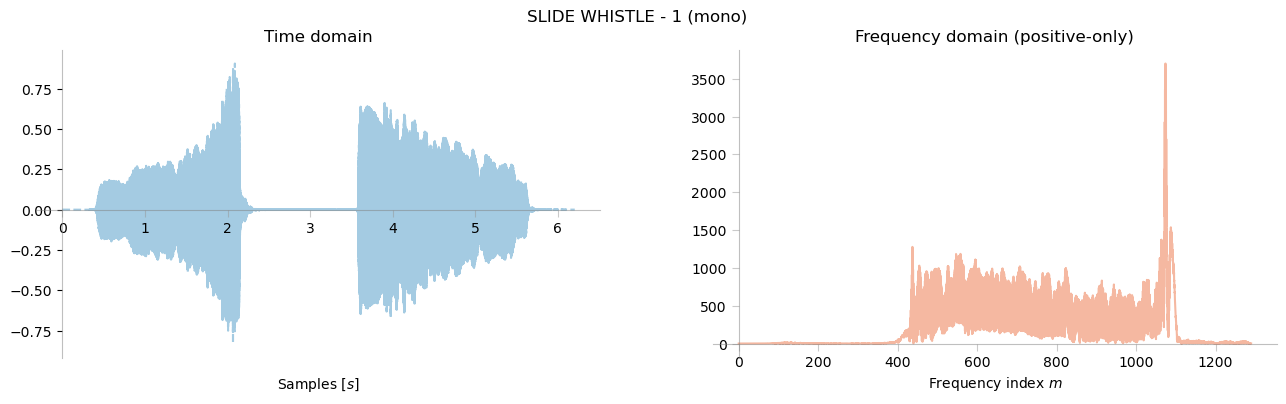

In [16]:
fig, (ax_time, ax_freq) = plt.subplots(nrows=1, ncols=2, figsize=(16, 4))

# 1st plot for the trumpet F3 waveform...
ax_time.plot(t, mono_x, color='#67a9cf', linestyle='--', alpha=0.6, zorder=-1)

ax_time.grid(False)
ax_time.set_title('Time domain')
# Eliminate upper and right axes
ax_time.spines['right'].set_color('none')
ax_time.spines['top'].set_color('none')

# Move left y-axis, passing through (0,0)
ax_time.spines['left'].set_position('zero')
ax_time.spines['left'].set_color('grey')
ax_time.spines['left'].set_alpha(0.5)

# Move bottom x-axis, passing through center of plot
ax_time.spines['bottom'].set_position('zero')
ax_time.spines['bottom'].set_color('grey')
ax_time.spines['bottom'].set_alpha(0.5)
ax_time.set_xlabel('Samples $[s]$')
ax_time.xaxis.set_label_coords(0.5, -0.06)
ax_time.tick_params(axis='x', which=u'both', length=5, color='#96969680')

# -----------------------------------
# 2nd plot for the corresponding DFT 
ax_freq.plot(freqs[:8000], np.abs(X_orig)[:8000], color='#ef8a62', alpha=0.6)

ax_freq.grid(False)
ax_freq.set_title('Frequency domain (positive-only)')
# Eliminate upper and right axes
ax_freq.spines['right'].set_color('none')
ax_freq.spines['top'].set_color('none')
ax_freq.spines['bottom'].set_color('none')

# Move left y-axis, passing through (0,0)
ax_freq.spines['left'].set_position('zero')
ax_freq.spines['left'].set_color('grey')
ax_freq.spines['left'].set_alpha(0.5)
ax_freq.tick_params(axis='y', which=u'both', length=5, color='#96969680')

# Move bottom x-axis, passing through center of plot
ax_freq.spines['bottom'].set_position('zero')
ax_freq.spines['bottom'].set_color('grey')
ax_freq.spines['bottom'].set_alpha(0.5)
#ax_freq.set_xticks(np.arange(0, fin_info.samplerate//2, 5000))
ax_freq.set_xlabel('Frequency index $m$')
ax_freq.tick_params(axis='x', which=u'both', length=5, color='#96969680')

plt.suptitle('SLIDE WHISTLE - 1 (mono)')
plt.show()

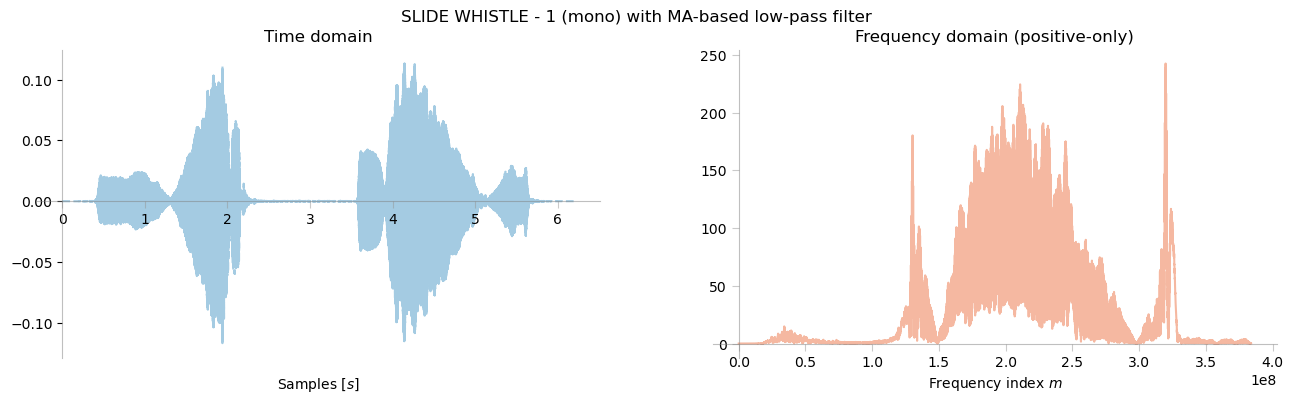

In [14]:
fig, (ax_time, ax_freq) = plt.subplots(nrows=1, ncols=2, figsize=(16, 4))

# 1st plot for the trumpet F3 waveform...
ax_time.plot(t_ma, y_ma, color='#67a9cf', linestyle='--', alpha=0.6, zorder=-1)

ax_time.grid(False)
ax_time.set_title('Time domain')
# Eliminate upper and right axes
ax_time.spines['right'].set_color('none')
ax_time.spines['top'].set_color('none')

# Move left y-axis, passing through (0,0)
ax_time.spines['left'].set_position('zero')
ax_time.spines['left'].set_color('grey')
ax_time.spines['left'].set_alpha(0.5)

# Move bottom x-axis, passing through center of plot
ax_time.spines['bottom'].set_position('zero')
ax_time.spines['bottom'].set_color('grey')
ax_time.spines['bottom'].set_alpha(0.5)
ax_time.set_xlabel('Samples $[s]$')
ax_time.xaxis.set_label_coords(0.5, -0.06)
ax_time.tick_params(axis='x', which=u'both', length=5, color='#96969680')

# -----------------------------------
# 2nd plot for the corresponding DFT 
ax_freq.plot(freqs_ma[:8000], np.abs(Y_ma)[:8000], color='#ef8a62', alpha=0.6)

ax_freq.grid(False)
ax_freq.set_title('Frequency domain (positive-only)')
# Eliminate upper and right axes
ax_freq.spines['right'].set_color('none')
ax_freq.spines['top'].set_color('none')
ax_freq.spines['bottom'].set_color('none')

# Move left y-axis, passing through (0,0)
ax_freq.spines['left'].set_position('zero')
ax_freq.spines['left'].set_color('grey')
ax_freq.spines['left'].set_alpha(0.5)
ax_freq.tick_params(axis='y', which=u'both', length=5, color='#96969680')

# Move bottom x-axis, passing through center of plot
ax_freq.spines['bottom'].set_position('zero')
ax_freq.spines['bottom'].set_color('grey')
ax_freq.spines['bottom'].set_alpha(0.5)
#ax_freq.set_xticks(np.arange(0, fin_info.samplerate//2, 5000))
ax_freq.set_xlabel('Frequency index $m$')
ax_freq.tick_params(axis='x', which=u'both', length=5, color='#96969680')

plt.suptitle('SLIDE WHISTLE - 1 (mono) with MA-based low-pass filter')
plt.show()

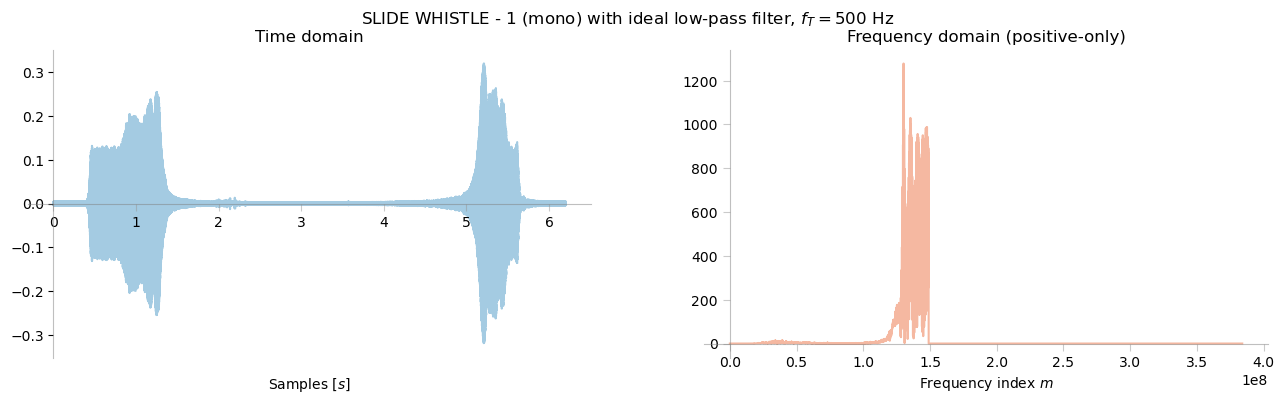

In [15]:
fig, (ax_time, ax_freq) = plt.subplots(nrows=1, ncols=2, figsize=(16, 4))

# 1st plot for the trumpet F3 waveform...
ax_time.plot(t, y_ideal, color='#67a9cf', linestyle='--', alpha=0.6, zorder=-1)

ax_time.grid(False)
ax_time.set_title('Time domain')
# Eliminate upper and right axes
ax_time.spines['right'].set_color('none')
ax_time.spines['top'].set_color('none')

# Move left y-axis, passing through (0,0)
ax_time.spines['left'].set_position('zero')
ax_time.spines['left'].set_color('grey')
ax_time.spines['left'].set_alpha(0.5)

# Move bottom x-axis, passing through center of plot
ax_time.spines['bottom'].set_position('zero')
ax_time.spines['bottom'].set_color('grey')
ax_time.spines['bottom'].set_alpha(0.5)
ax_time.set_xlabel('Samples $[s]$')
ax_time.xaxis.set_label_coords(0.5, -0.06)
ax_time.tick_params(axis='x', which=u'both', length=5, color='#96969680')

# -----------------------------------
# 2nd plot for the corresponding DFT 
ax_freq.plot(freqs_ideal[:8000], np.abs(Y_ideal)[:8000], color='#ef8a62', alpha=0.6)

ax_freq.grid(False)
ax_freq.set_title('Frequency domain (positive-only)')
# Eliminate upper and right axes
ax_freq.spines['right'].set_color('none')
ax_freq.spines['top'].set_color('none')
ax_freq.spines['bottom'].set_color('none')

# Move left y-axis, passing through (0,0)
ax_freq.spines['left'].set_position('zero')
ax_freq.spines['left'].set_color('grey')
ax_freq.spines['left'].set_alpha(0.5)
ax_freq.tick_params(axis='y', which=u'both', length=5, color='#96969680')

# Move bottom x-axis, passing through center of plot
ax_freq.spines['bottom'].set_position('zero')
ax_freq.spines['bottom'].set_color('grey')
ax_freq.spines['bottom'].set_alpha(0.5)
#ax_freq.set_xticks(np.arange(0, fin_info.samplerate//2, 5000))
ax_freq.set_xlabel('Frequency index $m$')
ax_freq.tick_params(axis='x', which=u'both', length=5, color='#96969680')

plt.suptitle('SLIDE WHISTLE - 1 (mono) with ideal low-pass filter, $f_{T} = 500$ Hz')
plt.show()

----

### 10.5 Exercises

#### Exercise 10.1

Given:
* signal $x$ of length $N$
* filter $h$ of length $K \lt N$

... the standard _full-mode_ convolution $h \ast x$ can be implemented via circular convolution on zero-padded versions of $x$ and $h$, and then trimming the results.

In terms of $N$ and $K$, what is the minimal amount of padding applied to $x$ and $h$ required for this idea to work?

##### _Answer_

* From the definition of full-mode convolution on page 59, we know that $x$ is padded both on the left and the right with zeroes such that the new length is $N + K - 1$
* In circular convolution, both signals need to be of the same length, so $h$ needs to be padded on the right with $N - 1$ zeroes.


----